# CSI4142 Assignment 2
Jonathan Cojita, Lucas Gavura

## Part 2: Imputation
Jonathan Cojita

In [ ]:
#Imports needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

/Users/jonathanc/dev/school/Data_Science/DataScienceA2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jonathanc/dev/school/Data_Science/DataScienceA2/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "yashdev01/spotify-tracks-dataset"
)

df = pd.read_csv(f"{path}/spotify-tracks-dataset.csv")
print(df.head())

   Unnamed: 0.1  Unnamed: 0                track_id                 artists  \
0             0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1             1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2             2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3             3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4             4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       1496

### 2.1:
**Type of Imputation**:
**Description of Imputation**:

**Type of Missing Data Simulated**: MCAR
**Attrtibute Affected**: Speechiness (how much spoken content is in the song)
**How Missing Data is Simulated**: We take a defined percentage of the dataset and at random, set that number of rows to have a null speechiness


speechiness - MCAR (Median)
Genre - MAR (Similarity Based)
Popularity - MCAR (Regression)


In [4]:
#Simulate MCAR over genre column
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)
missing_indices = np.random.choice(df.index, n_missing, replace=False)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values = df.loc[missing_indices, 'speechiness'].copy()

df.loc[missing_indices, 'speechiness'] = np.nan

#Print missing value row sample (Print track, artist, and genre)
print(df[df['speechiness'].isna()].head()[['track_name', 'artists', 'speechiness']])

                    track_name                               artists  \
3   Can't Help Falling In Love                          Kina Grannis   
22               Say Something  A Great Big World;Christina Aguilera   
64           Always Be My Baby                          Tim Halperin   
67         She Used To Be Mine                        Sara Bareilles   
73        You're Still The One                           Bailey Jehl   

    speechiness  
3           NaN  
22          NaN  
64          NaN  
67          NaN  
73          NaN  


In [ ]:
#Train a regression model to predict missing popularity


Mean speechiness: 0.08463435477582847


In [6]:
#Impute missing values with mode
imputed_indices = df[df['speechiness'].isna()].index
df['speechiness'] = df['speechiness'].fillna(mean_speechiness)

#Print the rows that were just imputed to confirm
print(f"Imputed {len(imputed_indices)} rows")
print(df.loc[imputed_indices, ['track_name', 'artists', 'speechiness']].head())

Imputed 11400 rows
                    track_name                               artists  \
3   Can't Help Falling In Love                          Kina Grannis   
22               Say Something  A Great Big World;Christina Aguilera   
64           Always Be My Baby                          Tim Halperin   
67         She Used To Be Mine                        Sara Bareilles   
73        You're Still The One                           Bailey Jehl   

    speechiness  
3      0.084634  
22     0.084634  
64     0.084634  
67     0.084634  
73     0.084634  


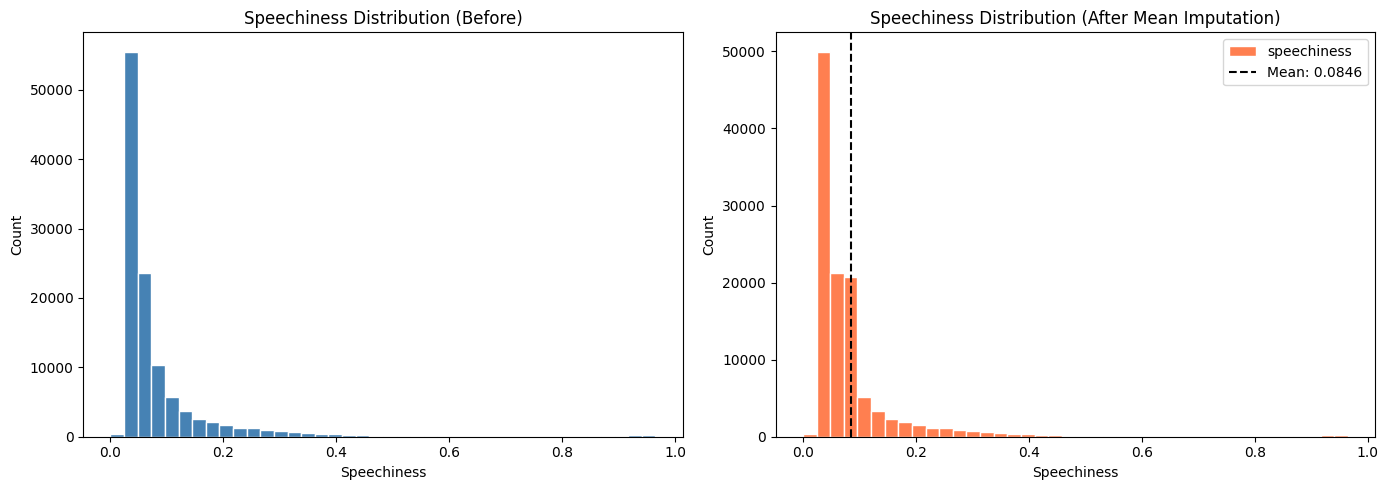

            Before     After     Delta
Mean      0.084652  0.084634 -0.000018
Median    0.048900  0.053200  0.004300
Std Dev   0.105732  0.100256 -0.005476
Skewness  4.647516  4.892277  0.244761


In [7]:
#Plot speechiness distribution before vs after imputation (full dataset)

# Reconstruct full "before" distribution: original values for imputed rows + untouched rows
before_full = pd.concat([
    original_genre_values,
    df.loc[~df.index.isin(missing_indices), 'speechiness']
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_full.plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Speechiness Distribution (Before)')
axes[0].set_xlabel('Speechiness')
axes[0].set_ylabel('Count')

df['speechiness'].plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(mean_speechiness, color='black', linestyle='--', label=f'Mean: {mean_speechiness:.4f}')
axes[1].set_title('Speechiness Distribution (After Mean Imputation)')
axes[1].set_xlabel('Speechiness')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

#Compare distribution statistics before and after imputation
stats = pd.DataFrame({
    'Before': [
        before_full.mean(),
        before_full.median(),
        before_full.std(),
        before_full.skew(),
    ],
    'After': [
        df['speechiness'].mean(),
        df['speechiness'].median(),
        df['speechiness'].std(),
        df['speechiness'].skew(),
    ]
}, index=['Mean', 'Median', 'Std Dev', 'Skewness'])

stats['Delta'] = stats['After'] - stats['Before']
print(stats.round(6))

**Analysis**: Observing the before and after distribution, it is aparent the change that our imputations made, however largley the distrtibution of the data overall seems similar. Looking at the distribution values we also see very slight changes between the values.

## 2.3

**Type of Missing Data Simulated**:

**Attrtibute Affected**:

**How Missing Data is Simulated**:


In [8]:
#Simulate MCAR over popularity column
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)
missing_indices = np.random.choice(df.index, n_missing, replace=False)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values = df.loc[missing_indices, 'popularity'].copy()

df.loc[missing_indices, 'popularity'] = np.nan

#Print missing value row sample (Print track, artist, and genre)
print(df[df['popularity'].isna()].head()[['track_name', 'artists', 'popularity']])

                 track_name                artists  popularity
1          Ghost - Acoustic           Ben Woodward         NaN
37  Throwing Good After Bad         Brandi Carlile         NaN
38       This Time Tomorrow         Brandi Carlile         NaN
43   You and Me on the Rock  Brandi Carlile;Lucius         NaN
52                   Pieces           Andrew Belle         NaN


In [ ]:
feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'explicit', 'mode', 'time_signature'
]

# Split df into rows where popularity is known vs missing
df_known = df[df['popularity'].notna()]
df_missing = df[df['popularity'].isna()]

# Split known rows into train/test to evaluate model performance
X = df_known[feature_cols]
y = df_known['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model on training portion of known rows
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate on held-out test set
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

In [ ]:
# Predict popularity for the MCAR-missing rows using the trained model
X_pred = df_missing[feature_cols]
predicted = model.predict(X_pred)

# Impute: fill NaN rows with predicted values
df.loc[df['popularity'].isna(), 'popularity'] = predicted

print(f"Imputed {len(df_missing)} rows")
print(df.loc[df_missing.index[:5], ['track_name', 'artists', 'popularity']])